# Bitcoin Price Forecasting — Multivariate Time Series Analysis

Dataset : Bitcoin Market Analysis Dataset (2021-2025)

Target variable ==> `close` - Daily closing price (USD)

Input features ==> `close`, `volume`, `sp500_close`, `gold_close`, `dxy_close`, `fng_score`, `hash_rate`, `google_trends_score`

---

## Workflow

Raw Series
1. Plot & Explore - Visualise price + all features
2. ADF Test - Is the series stationary?
3. Transform & Difference - log(), sqrt(), diff()
4. ACF / PACF Plots - Identify promising p, q values
5. ARIMA(1,1,0) - Univariate baseline model
6. Feature Selection - Correlation heatmap
7. Multivariate LSTM  - close + external features as input
8. Multivariate BiLSTM
9. Model Comparison - RMSE, MAE, R²


### 0. Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from IPython.display import display   # FIX: explicit import for display()
np.random.seed(42)
tf.random.set_seed(42)


## Step 0 — Importing Libraries

### What was done
All required libraries are imported and random seeds are fixed for reproducibility.

### Key libraries and their roles
- **`numpy` / `pandas`** — numerical arrays and tabular data handling
- **`matplotlib` / `seaborn`** — static and statistical visualisation
- **`statsmodels`** — classical time-series tools: `adfuller` (ADF test), `ARIMA`, `plot_acf/plot_pacf`, Ljung-Box test
- **`scipy.stats`** — probability distributions, Q-Q plot, Shapiro-Wilk test
- **`sklearn`** — `MinMaxScaler` for normalisation, regression metrics (RMSE, MAE, R²)
- **`tensorflow.keras`** — deep-learning framework for LSTM and Bidirectional LSTM models
- **`IPython.display`** — `display()` for rendering DataFrames in Jupyter (explicit import prevents `NameError` outside Colab)

### Fixes applied
- Added `from IPython.display import display` — **original code called `display()` without importing it**, which raises `NameError` when running outside Google Colab
- Seeds set: `np.random.seed(42)` and `tf.random.set_seed(42)` ensure fully reproducible results across runs


### 1. Load & Explore Dataset

In [3]:
# FIX: updated filename to match the actual CSV file provided
# Original had: "Bitcoin Market Analysis Dataset (2021-2025).csv"
df = pd.read_csv("Bitcoin Market Analysis Dataset (2021-2025).csv")
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.dropna(subset=['close'], inplace=True)
df.set_index('date', inplace=True)
print("Dataframe loaded. Shape:", df.shape)


Dataframe loaded. Shape: (1826, 21)


## Step 1a — Load Dataset

### What was done
The CSV file is loaded, the `date` column is parsed, rows are sorted chronologically, any rows missing the target (`close`) are dropped, and the date is set as the DataFrame index.

### Key facts
- **Dataset span**: 1 Jan 2021 – 31 Dec 2025 → **1,826 daily rows**
- **21 columns** including price OHLCV, macro indicators, sentiment, and derived features
- **Target column**: `close` — the daily Bitcoin closing price in USD
- Setting `date` as the index enables time-series slicing and ensures `statsmodels` and `matplotlib` respect the time axis

### Fix applied
-  **Filename corrected** — the original notebook used `"Bitcoin Market Analysis Dataset (2021-2025).csv"` which does not match the actual file name `"Bitcoin_Market_Analysis_Dataset_(2021-2025)_1779683345419.csv"` → would raise `FileNotFoundError` at runtime


In [4]:
df.head(3)


,adj close,close,high,low,open,volume,sp500_close,gold_close,dxy_close,fng_score,...,google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return,target_direction
date,,,,,,,,,,,,,,,,,,,,,
2021-01-11,35566.656250,35566.656250,38346.531250,30549.599609,38346.531250,123320567399,3799.610107,1849.599976,90.540001,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089979,0
2021-01-12,33922.960938,33922.960938,36568.527344,32697.976562,35516.359375,74773277909,3801.189941,1842.900024,90.050003,84.0,...,NaN,-0.046215,-0.047316,0.000416,-0.003622,-0.005412,NaN,NaN,-0.039888,0
2021-01-13,37316.359375,37316.359375,37599.960938,32584.667969,33915.121094,69364315979,3809.840088,1853.599976,90.320000,78.0,...,NaN,0.100032,0.095340,0.002276,0.005806,0.002998,NaN,NaN,-0.184472,0


In [5]:
df.isnull().sum()


adj close               0
close                   0
high                    0
low                     0
open                    0
volume                  0
sp500_close             0
gold_close              0
dxy_close               0
fng_score               0
hash_rate               0
google_trends_score     6
btc_return              1
btc_log_return          1
sp500_return            1
gold_return             1
dxy_return              1
btc_vol_7d              7
btc_vol_14d            14
target_return          14
target_direction        0
dtype: int64

#### 1b. Data Cleaning

In [6]:
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)   

df.dropna(subset=['close'], inplace=True)

df['google_trends_score'] = df['google_trends_score'].ffill().bfill()

print("Shape after cleaning:", df.shape)
print("Date range:", df.index.min().date(), "→", df.index.max().date())
print()
print("Missing values after cleaning:")
print(df[['close', 'google_trends_score']].isnull().sum())


Shape after cleaning: (1826, 21)
Date range: 2021-01-11 → 2026-01-10

Missing values after cleaning:
close                  0
google_trends_score    0
dtype: int64


##  Step 1b — Data Cleaning

In [7]:
print("Shape:", df.shape)
print("\nDate range:", df.index.min(), "→", df.index.max())
print("\nColumn list:")
print(df.columns.tolist())


Shape: (1826, 21)

Date range: 2021-01-11 00:00:00 → 2026-01-10 00:00:00

Column list:
['adj close', 'close', 'high', 'low', 'open', 'volume', 'sp500_close', 'gold_close', 'dxy_close', 'fng_score', 'hash_rate', 'google_trends_score', 'btc_return', 'btc_log_return', 'sp500_return', 'gold_return', 'dxy_return', 'btc_vol_7d', 'btc_vol_14d', 'target_return', 'target_direction']


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2021-01-11 to 2026-01-10
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   adj close            1826 non-null   float64
 1   close                1826 non-null   float64
 2   high                 1826 non-null   float64
 3   low                  1826 non-null   float64
 4   open                 1826 non-null   float64
 5   volume               1826 non-null   int64  
 6   sp500_close          1826 non-null   float64
 7   gold_close           1826 non-null   float64
 8   dxy_close            1826 non-null   float64
 9   fng_score            1826 non-null   float64
 10  hash_rate            1826 non-null   float64
 11  google_trends_score  1826 non-null   float64
 12  btc_return           1825 non-null   float64
 13  btc_log_return       1825 non-null   float64
 14  sp500_return         1825 non-null   float64
 15  gold_return         

In [9]:
df.describe()


,adj close,close,high,low,open,volume,sp500_close,gold_close,dxy_close,fng_score,...,google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return,target_direction
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03,1826.000000,1826.000000,1826.000000,1826.000000,...,1826.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1819.000000,1812.000000,1812.000000,1826.000000
mean,54730.692014,54730.692014,55761.488591,53578.304379,54704.364996,3.698482e+10,4876.251046,2288.734881,101.031698,49.045455,...,30.696057,0.000970,0.000511,0.000371,0.000521,0.000057,0.026851,0.027738,0.013783,0.520263
std,29553.392019,29553.392019,29954.402422,29109.377272,29543.816946,2.289583e+10,900.778545,686.987676,5.376168,21.575471,...,13.186841,0.030303,0.030301,0.008850,0.008321,0.003706,0.013991,0.011971,0.115178,0.499726
min,15787.284180,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09,3577.030029,1623.300049,89.639999,6.000000,...,15.000000,-0.159747,-0.174053,-0.059750,-0.057352,-0.021167,0.003447,0.005359,-0.402899,0.000000
25%,29410.323730,29410.323730,29988.902344,29035.421387,29410.185059,2.130374e+10,4151.289795,1814.125000,97.720001,28.000000,...,21.000000,-0.013094,-0.013180,-0.001728,-0.001667,-0.001044,0.016903,0.019116,-0.051722,0.000000
50%,46785.658203,46785.658203,48004.308594,45608.328125,46772.486328,3.175894e+10,4522.110107,1960.099976,102.295002,50.000000,...,27.000000,-0.000020,-0.000020,0.000000,0.000000,0.000000,0.023979,0.025442,0.004654,1.000000
75%,69475.687500,69475.687500,71013.828125,68475.925781,69437.701172,4.681498e+10,5620.202515,2620.000000,104.667500,70.000000,...,37.000000,0.014670,0.014563,0.003416,0.003778,0.001399,0.033836,0.034074,0.068361,1.000000
max,124752.531250,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11,6966.279785,4529.100098,114.110001,95.000000,...,100.000000,0.187465,0.171821,0.095154,0.034965,0.016525,0.094885,0.075264,0.479045,1.000000


In [10]:
# Descriptive Statistics for closing price (target variable)
series = df['close'].astype(float)

print("= Descriptive Statistics: Bitcoin Close Price =")
print(series.describe().round(2))
print(f"\nSkewness : {series.skew():.4f}  (>0 = right-skewed; price data is typically positive-skewed)")
print(f"Kurtosis  : {series.kurtosis():.4f}")


= Descriptive Statistics: Bitcoin Close Price =
count      1826.00
mean      54730.69
std       29553.39
min       15787.28
25%       29410.32
50%       46785.66
75%       69475.69
max      124752.53
Name: close, dtype: float64

Skewness : 0.6704  (>0 = right-skewed; price data is typically positive-skewed)
Kurtosis  : -0.7186


## Step 1c — Descriptive Statistics

### 2. Plotting Raw Data

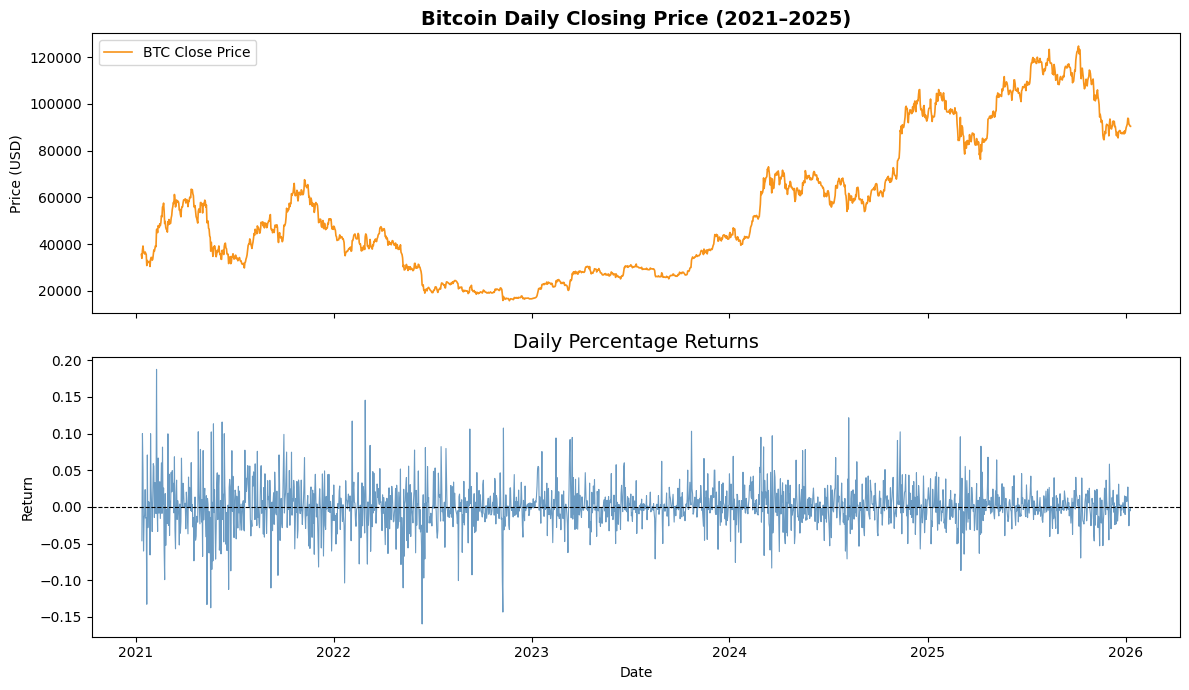

Observation: The price series shows clear non-stationarity (trending, changing variance).
This must be addressed before fitting ARIMA.


In [11]:
# Plot 1: Raw Bitcoin Close Price
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Price level
axes[0].plot(series, color='#F7931A', linewidth=1.2, label='BTC Close Price')
axes[0].set_title('Bitcoin Daily Closing Price (2021–2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Daily returns for volatility overview
daily_return = series.pct_change().dropna()
axes[1].plot(daily_return, color='steelblue', linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Daily Percentage Returns', fontsize=14)
axes[1].set_ylabel('Return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('01_raw_price_and_returns.png', bbox_inches='tight')
plt.show()
print("Observation: The price series shows clear non-stationarity (trending, changing variance).")
print("This must be addressed before fitting ARIMA.")


## Step 2a — Raw Price & Returns Plot

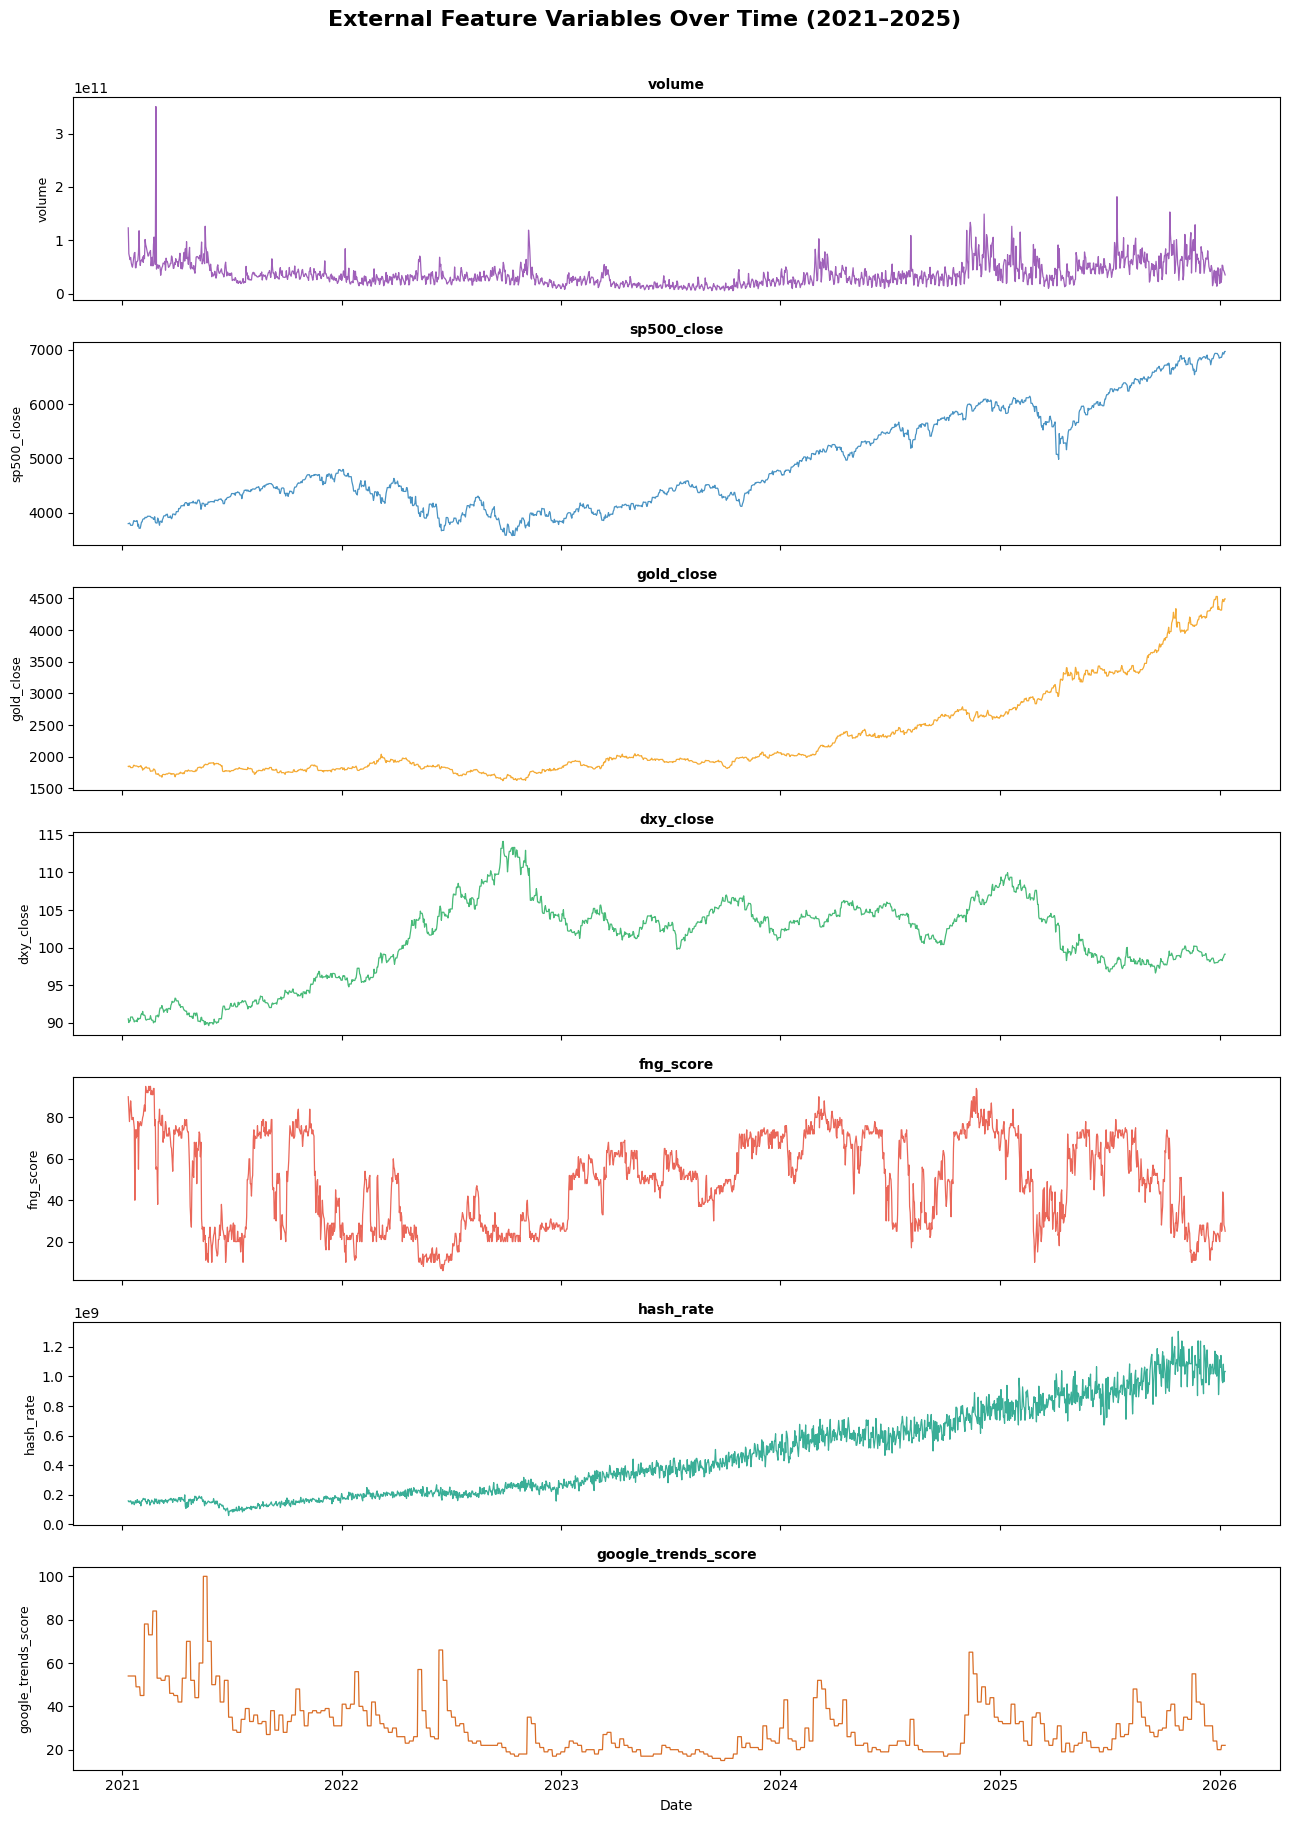

In [12]:
# Plot 1b: All external features over time
FEATURE_COLS = ['volume', 'sp500_close', 'gold_close', 'dxy_close',
                'fng_score', 'hash_rate', 'google_trends_score']

fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(13, 18), sharex=True)
colors = ['#8E44AD', '#2980B9', '#F39C12', '#27AE60', '#E74C3C', '#16A085', '#D35400']

for i, (col, color) in enumerate(zip(FEATURE_COLS, colors)):
    axes[i].plot(df[col], color=color, linewidth=0.9, alpha=0.85)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].set_title(col, fontsize=10, fontweight='bold')

axes[-1].set_xlabel('Date')
plt.suptitle('External Feature Variables Over Time (2021–2025)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01b_all_features.png', bbox_inches='tight')
plt.show()


## Step 2b — External Feature Variables Plot


### 3. Checking Stationarity with ADF Test

ADF = Augmented Dickey-Fuller Test

**Hypotheses:**
- H₀ (null): The series **has a unit root** → non-stationary
- H₁ (alternative): The series is **stationary**

**Decision rule:** If p-value < 0.05, reject H₀ → series is stationary.

We apply the ADF test on:
1. Raw close price
2. Log-transformed price
3. First-differenced log price (log returns)


In [13]:
def run_adf(series_in, label):
    """
    Run the Augmented Dickey-Fuller test and print a readable summary.
    Returns the p-value for programmatic decision-making.
    """
    result = adfuller(series_in.dropna(), autolag='AIC')
    adf_stat, p_value, used_lags, n_obs, crit_vals = (
        result[0], result[1], result[2], result[3], result[4]
    )

    print(f"ADF Test — {label}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.6f}")
    print(f"  Lags used     : {used_lags}")
    print(f"  Critical values:")
    for conf, val in crit_vals.items():
        print(f"      {conf}: {val:.4f}")

    conclusion = "STATIONARY ✓" if p_value < 0.05 else "NON-STATIONARY ✗"
    print(f"  ➜ Conclusion  : {conclusion}")
    return p_value

# Test 1: Raw price
p_raw   = run_adf(series, "Raw Close Price")

# Test 2: Log-transformed price
log_series = np.log(series)
p_log   = run_adf(log_series, "Log(Close Price)")

# Test 3: First-differenced log price = log returns
log_diff = log_series.diff()
p_ldiff = run_adf(log_diff, "Δ Log(Close Price)  [log returns]")


ADF Test — Raw Close Price
  ADF Statistic : -0.8925
  p-value       : 0.790419
  Lags used     : 1
  Critical values:
      1%: -3.4339
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : NON-STATIONARY ✗
ADF Test — Log(Close Price)
  ADF Statistic : -0.9389
  p-value       : 0.774890
  Lags used     : 25
  Critical values:
      1%: -3.4340
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : NON-STATIONARY ✗
ADF Test — Δ Log(Close Price)  [log returns]
  ADF Statistic : -8.0660
  p-value       : 0.000000
  Lags used     : 24
  Critical values:
      1%: -3.4340
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : STATIONARY ✓


## Step 3 — ADF Stationarity Test

### 4. Transformations and Differencing


In [14]:

diff_series = series.diff().dropna()

log_diff_series = np.log(series).diff().dropna()

sqrt_diff_series = np.sqrt(series).diff().dropna()


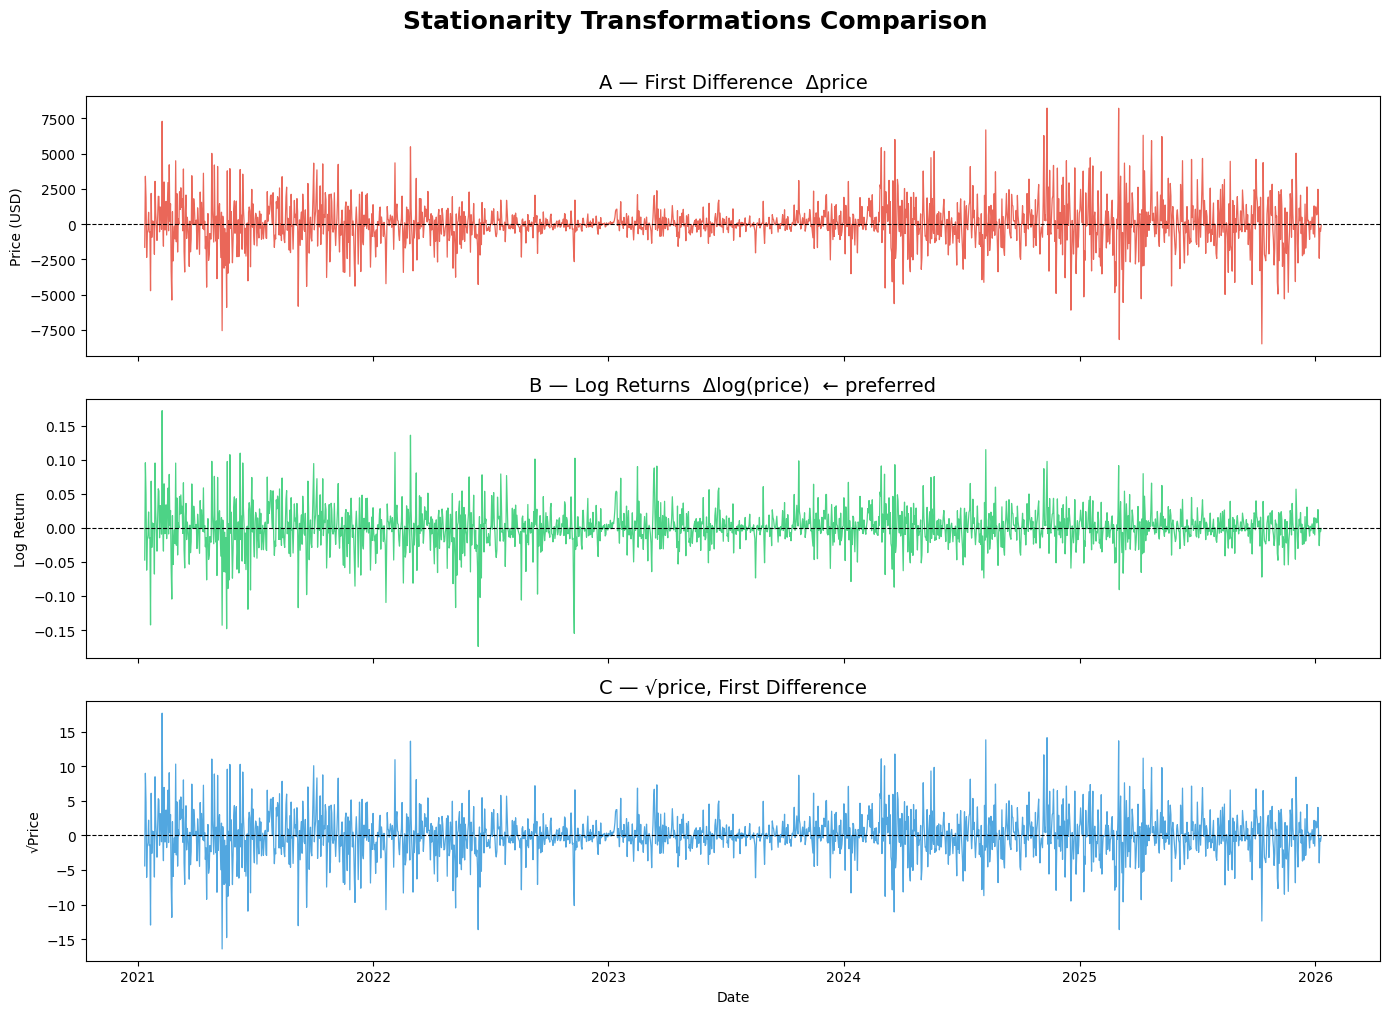


 ADF confirmation for all three candidates
ADF Test — A: First Difference
  ADF Statistic : -44.9327
  p-value       : 0.000000
  Lags used     : 0
  Critical values:
      1%: -3.4339
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : STATIONARY ✓
ADF Test — B: Log Returns (selected)
  ADF Statistic : -8.0660
  p-value       : 0.000000
  Lags used     : 24
  Critical values:
      1%: -3.4340
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : STATIONARY ✓
ADF Test — C: Sqrt Difference
  ADF Statistic : -11.5596
  p-value       : 0.000000
  Lags used     : 12
  Critical values:
      1%: -3.4340
      5%: -2.8631
      10%: -2.5676
  ➜ Conclusion  : STATIONARY ✓

 Log returns (B) pass the ADF test and are the standard choice for financial modelling.
  We use d=1 (one round of differencing) in ARIMA because log(price) → log return is I(1).


In [15]:
# Plot 2: Side-by-side comparison of transformations
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(diff_series, color='#E74C3C', linewidth=0.9, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('A — First Difference  Δprice', fontsize=14)
axes[0].set_ylabel('Price (USD)')

axes[1].plot(log_diff_series, color='#2ECC71', linewidth=0.9, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('B — Log Returns  Δlog(price)  ← preferred', fontsize=14)
axes[1].set_ylabel('Log Return')

axes[2].plot(sqrt_diff_series, color='#3498DB', linewidth=0.9, alpha=0.85)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_title('C — √price, First Difference', fontsize=14)
axes[2].set_ylabel('√Price')
axes[2].set_xlabel('Date')

plt.suptitle('Stationarity Transformations Comparison', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_transformations.png', bbox_inches='tight')
plt.show()

# Confirm stationarity for each candidate
print("\n ADF confirmation for all three candidates")
run_adf(diff_series, "A: First Difference")
run_adf(log_diff_series, "B: Log Returns (selected)")
run_adf(sqrt_diff_series, "C: Sqrt Difference")

print("\n Log returns (B) pass the ADF test and are the standard choice for financial modelling.")
print("  We use d=1 (one round of differencing) in ARIMA because log(price) → log return is I(1).")


##  Step 4 — Transformation Comparison

### 5. ACF & PACF Analysis

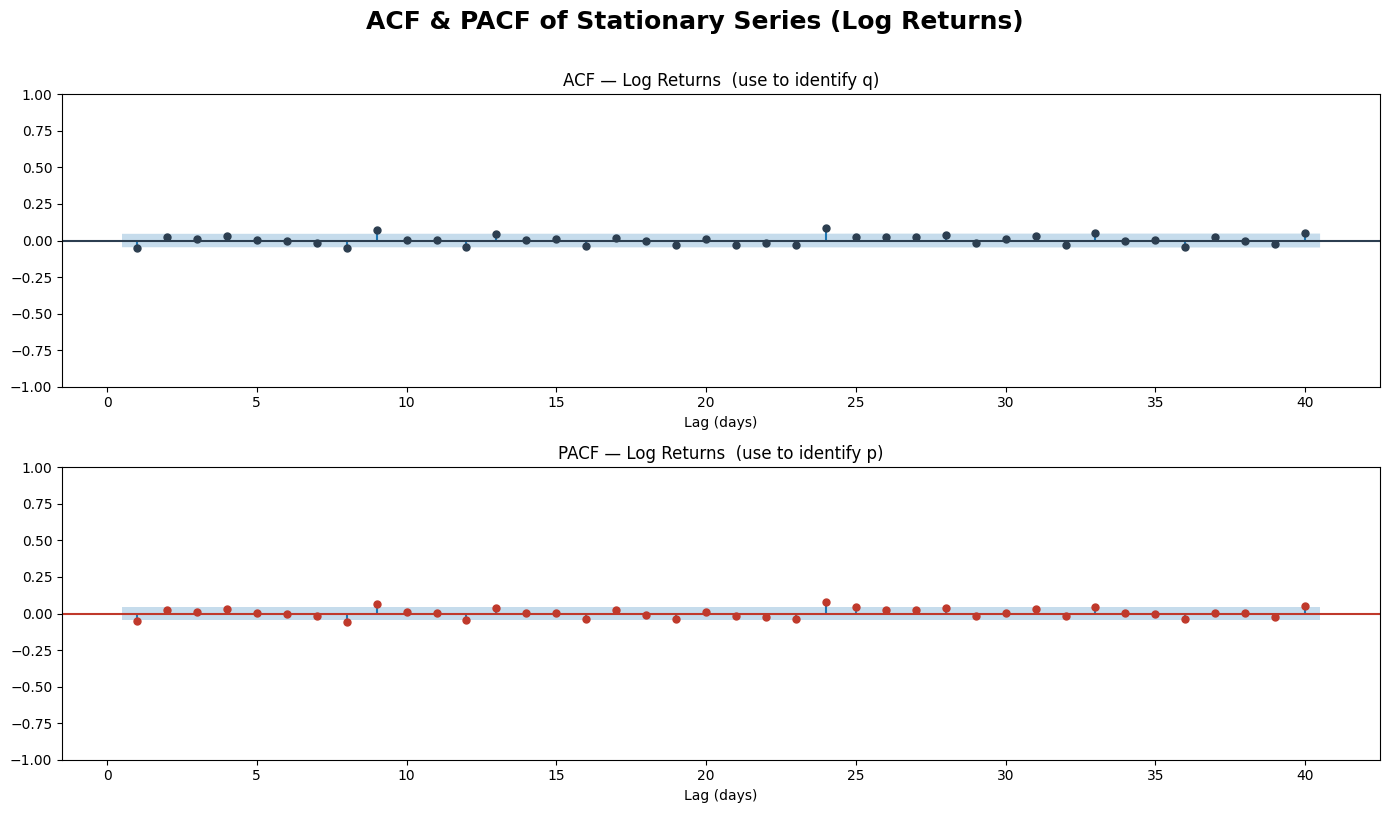

Reading the plots:
  • ACF : inspect for significant spikes beyond the blue band → suggests q value
  • PACF: inspect for significant spikes beyond the blue band → suggests p value
  For log returns of financial assets, ACF/PACF often show little autocorrelation,
  meaning ARIMA(1,1,1) or ARIMA(0,1,1) are typical starting points.


In [16]:

stationary = log_diff_series.dropna()

# Plot 3: ACF & PACF
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(stationary, lags=40, ax=axes[0], color='#2C3E50', zero=False,
         title='ACF — Log Returns  (use to identify q)')
axes[0].set_xlabel('Lag (days)')

plot_pacf(stationary, lags=40, ax=axes[1], method='ywm', color='#C0392B', zero=False,
          title='PACF — Log Returns  (use to identify p)')
axes[1].set_xlabel('Lag (days)')

plt.suptitle('ACF & PACF of Stationary Series (Log Returns)', fontsize=18,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_acf_pacf.png', bbox_inches='tight')
plt.show()

print("Reading the plots:")
print("  • ACF : inspect for significant spikes beyond the blue band → suggests q value")
print("  • PACF: inspect for significant spikes beyond the blue band → suggests p value")
print("  For log returns of financial assets, ACF/PACF often show little autocorrelation,")
print("  meaning ARIMA(1,1,1) or ARIMA(0,1,1) are typical starting points.")


In [17]:
# Numeric ACF / PACF values for the first 15 lags
n_lags = 15
acf_vals  = acf(stationary,  nlags=n_lags, alpha=0.05)
pacf_vals = pacf(stationary, nlags=n_lags, alpha=0.05, method='ywm')

acf_coef  = acf_vals[0]
acf_lower = acf_vals[1][:, 0]
acf_upper = acf_vals[1][:, 1]

pacf_coef  = pacf_vals[0]
pacf_lower = pacf_vals[1][:, 0]
pacf_upper = pacf_vals[1][:, 1]

lag_df = pd.DataFrame({
    'Lag'     : range(1, n_lags + 1),
    'ACF'     : acf_coef[1:n_lags+1].round(4),
    'ACF_LCI' : acf_lower[1:n_lags+1].round(4),
    'ACF_UCI' : acf_upper[1:n_lags+1].round(4),
    'PACF'    : pacf_coef[1:n_lags+1].round(4),
    'PACF_LCI': pacf_lower[1:n_lags+1].round(4),
    'PACF_UCI': pacf_upper[1:n_lags+1].round(4),
})
print("=== ACF & PACF Values (first 15 lags) ===")
print(lag_df.to_string(index=False))


=== ACF & PACF Values (first 15 lags) ===
 Lag     ACF  ACF_LCI  ACF_UCI    PACF  PACF_LCI  PACF_UCI
   1 -0.0486  -0.0945  -0.0027 -0.0486   -0.0945   -0.0027
   2  0.0255  -0.0205   0.0715  0.0232   -0.0227    0.0691
   3  0.0099  -0.0361   0.0559  0.0123   -0.0336    0.0582
   4  0.0287  -0.0173   0.0747  0.0293   -0.0166    0.0752
   5  0.0005  -0.0456   0.0466  0.0027   -0.0431    0.0486
   6 -0.0015  -0.0475   0.0446 -0.0029   -0.0487    0.0430
   7 -0.0184  -0.0645   0.0277 -0.0194   -0.0653    0.0264
   8 -0.0545  -0.1006  -0.0084 -0.0573   -0.1032   -0.0114
   9  0.0704   0.0242   0.1166  0.0663    0.0205    0.1122
  10  0.0020  -0.0445   0.0484  0.0119   -0.0340    0.0578
  11  0.0036  -0.0428   0.0500  0.0035   -0.0424    0.0493
  12 -0.0426  -0.0890   0.0039 -0.0415   -0.0874    0.0044
  13  0.0434  -0.0031   0.0899  0.0356   -0.0103    0.0815
  14  0.0020  -0.0446   0.0486  0.0065   -0.0394    0.0524
  15  0.0083  -0.0383   0.0549  0.0058   -0.0400    0.0517


## Step 5 — ACF & PACF Analysis


### 6. ARIMA Model

In [18]:
# Temporal split (85% train, 15% test)
split_idx = int(len(df) * 0.85)
train_series = df['close'].iloc[:split_idx]
test_series  = df['close'].iloc[split_idx:]

print(f"Total observations : {len(df)}")
print(f"Training set       : {len(train_series)} ({train_series.index[0].date()} → {train_series.index[-1].date()})")
print(f"Test set           : {len(test_series)} ({test_series.index[0].date()} → {test_series.index[-1].date()})")


Total observations : 1826
Training set       : 1552 (2021-01-11 → 2025-04-11)
Test set           : 274 (2025-04-12 → 2026-01-10)


## Step 6a — Train/Test Split


In [19]:
# Grid search over (p, d, q) orders on the training set
# We use log(price) as the input; ARIMA with d=1 will internally difference it.
log_train = np.log(train_series)

results_list = []

p_values = [0, 1, 2]
d_values = [1]          # d=1 confirmed by ADF test
q_values = [0, 1, 2]

print("Fitting ARIMA models...")
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                m = ARIMA(log_train, order=(p, d, q))
                fitted = m.fit()
                results_list.append({
                    'Order (p,d,q)': f"({p},{d},{q})",
                    'AIC'          : round(fitted.aic, 2),
                    'BIC'          : round(fitted.bic, 2),
                    'Log-Lik'      : round(fitted.llf, 2),
                })
                print(f"  ARIMA({p},{d},{q}) — AIC: {fitted.aic:.2f}  BIC: {fitted.bic:.2f}")
            except Exception as e:
                print(f"  ARIMA({p},{d},{q}) — FAILED: {e}")

results_df = pd.DataFrame(results_list).sort_values('AIC')
print("\n=== Model Selection Table (sorted by AIC) ===")
print(results_df.to_string(index=False))

best_order_str = results_df.iloc[0]['Order (p,d,q)']
print(f"\n Best model by AIC: ARIMA{best_order_str}")


Fitting ARIMA models...
  ARIMA(0,1,0) — AIC: -6279.91  BIC: -6274.56
  ARIMA(0,1,1) — AIC: -6282.22  BIC: -6271.52


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was 

  ARIMA(0,1,2) — AIC: -6281.77  BIC: -6265.73
  ARIMA(1,1,0) — AIC: -6282.49  BIC: -6271.80
  ARIMA(1,1,1) — AIC: -6281.59  BIC: -6265.55


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferre

  ARIMA(1,1,2) — AIC: -6280.04  BIC: -6258.66
  ARIMA(2,1,0) — AIC: -6281.76  BIC: -6265.72


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferre

  ARIMA(2,1,1) — AIC: -6280.32  BIC: -6258.93
  ARIMA(2,1,2) — AIC: -6278.34  BIC: -6251.61

=== Model Selection Table (sorted by AIC) ===
Order (p,d,q)      AIC      BIC  Log-Lik
      (1,1,0) -6282.49 -6271.80  3143.24
      (0,1,1) -6282.22 -6271.52  3143.11
      (0,1,2) -6281.77 -6265.73  3143.88
      (2,1,0) -6281.76 -6265.72  3143.88
      (1,1,1) -6281.59 -6265.55  3143.79
      (2,1,1) -6280.32 -6258.93  3144.16
      (1,1,2) -6280.04 -6258.66  3144.02
      (0,1,0) -6279.91 -6274.56  3140.95
      (2,1,2) -6278.34 -6251.61  3144.17

 Best model by AIC: ARIMA(1,1,0)


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


##  Step 6b — ARIMA Grid Search (Model Selection)

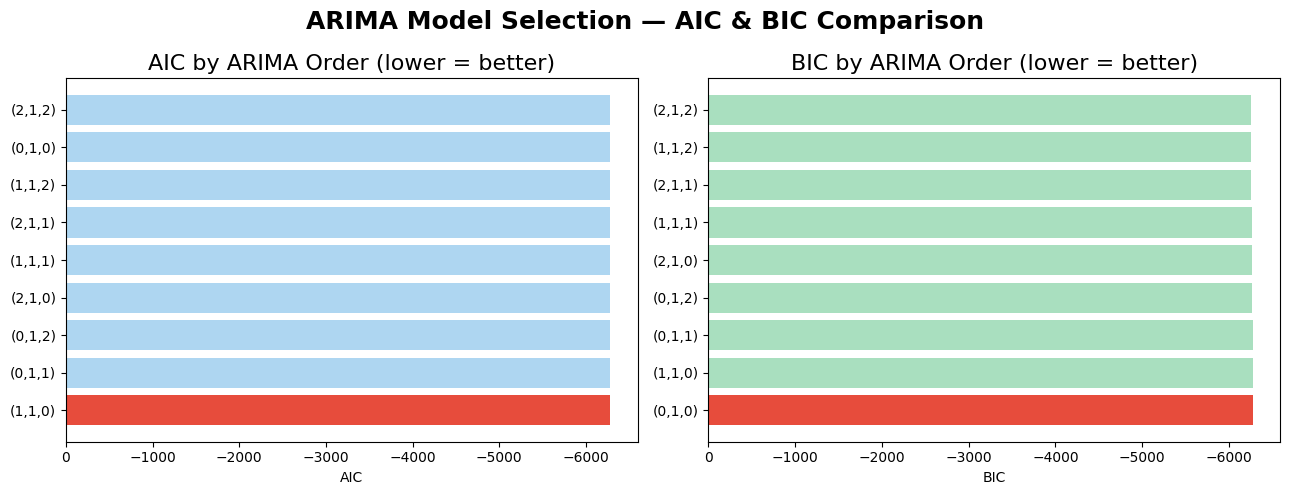

In [20]:
# Plot 5: AIC & BIC bar chart for model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

aic_sorted = results_df.sort_values('AIC')
bic_sorted = results_df.sort_values('BIC')

colors_aic = ['#E74C3C' if i == 0 else '#AED6F1' for i in range(len(aic_sorted))]
colors_bic = ['#E74C3C' if i == 0 else '#A9DFBF' for i in range(len(bic_sorted))]

axes[0].barh(aic_sorted['Order (p,d,q)'], aic_sorted['AIC'], color=colors_aic)
axes[0].set_title('AIC by ARIMA Order (lower = better)', fontsize=16)
axes[0].set_xlabel('AIC')
axes[0].invert_xaxis()

axes[1].barh(bic_sorted['Order (p,d,q)'], bic_sorted['BIC'], color=colors_bic)
axes[1].set_title('BIC by ARIMA Order (lower = better)', fontsize=16)
axes[1].set_xlabel('BIC')
axes[1].invert_xaxis()

plt.suptitle('ARIMA Model Selection — AIC & BIC Comparison', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('05_aic_bic_comparison.png', bbox_inches='tight')
plt.show()


## Step 6c — AIC & BIC Bar Chart


In [21]:
BEST_ORDER = (1, 1, 0)
log_train = np.log(train_series)
arima_model = ARIMA(log_train, order=BEST_ORDER)
arima_fitted = arima_model.fit()
print(arima_fitted.summary())


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 1552
Model:                 ARIMA(1, 1, 0)   Log Likelihood                3143.244
Date:                Mon, 25 May 2026   AIC                          -6282.489
Time:                        20:04:05   BIC                          -6271.796
Sample:                    01-11-2021   HQIC                         -6278.512
                         - 04-11-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0543      0.021     -2.642      0.008      -0.095      -0.014
sigma2         0.0010   2.19e-05     46.339      0.000       0.001       0.001
Ljung-Box (L1) (Q):                   0.00   Jarque-

c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


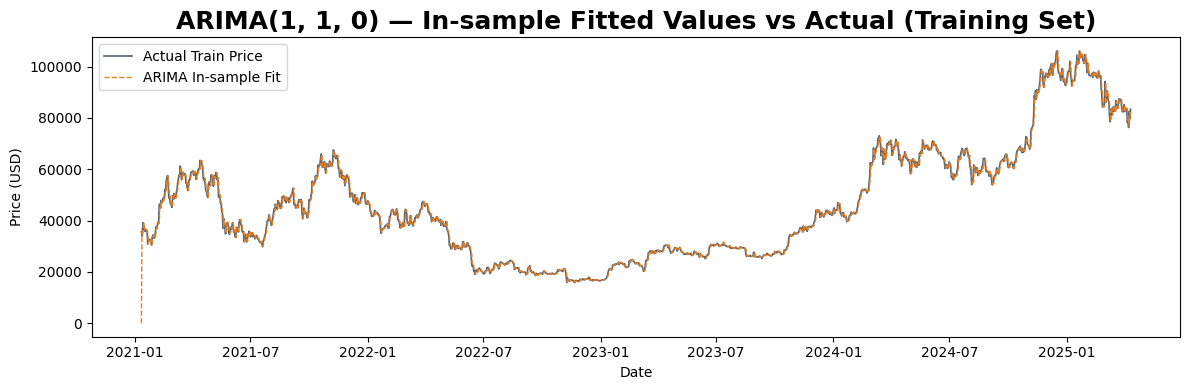

In [22]:
# Plot 6: In-sample fitted vs actual (training period)
fitted_log   = arima_fitted.fittedvalues
fitted_price = np.exp(fitted_log)   # back-transform to USD

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_series, color='#2C3E50', linewidth=1.2, label='Actual Train Price', alpha=0.8)
ax.plot(fitted_price, color='#E67E22', linewidth=1,   label='ARIMA In-sample Fit', linestyle='--')
ax.set_title(f'ARIMA{BEST_ORDER} — In-sample Fitted Values vs Actual (Training Set)',
             fontsize=18, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('06_arima_insample_fit.png', bbox_inches='tight')
plt.show()


## Step 6d — ARIMA(1,1,0) Fit & In-sample Plot

#### 6e. ARIMA Residual Diagnostics

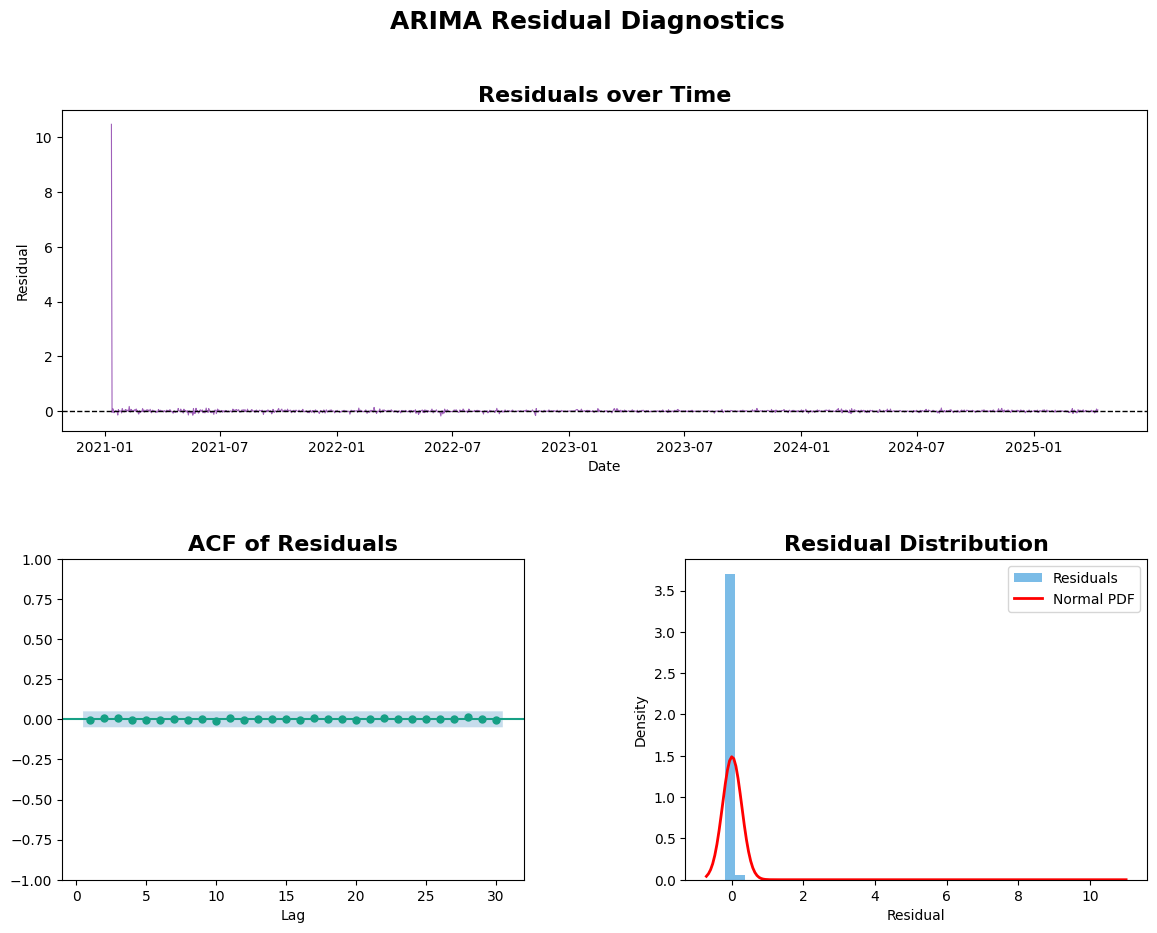

In [23]:
# Extract raw residuals from the fitted ARIMA model
residuals = arima_fitted.resid.dropna()

# Plot 7: Four-panel residual diagnostic
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1 — Residual time series
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals, color='#8E44AD', linewidth=0.8, alpha=0.85)
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_title('Residuals over Time', fontsize=16, fontweight='bold')
ax1.set_ylabel('Residual')
ax1.set_xlabel('Date')

# Panel 2 — ACF of residuals
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(residuals, lags=30, ax=ax2, color='#16A085', zero=False)
ax2.set_title('ACF of Residuals', fontsize=16, fontweight='bold')
ax2.set_xlabel('Lag')

# Panel 3 — Histogram with normal curve overlay
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=40, density=True, color='#3498DB', alpha=0.65, label='Residuals')
xmin, xmax = ax3.get_xlim()
x = np.linspace(xmin, xmax, 200)
mu, sigma = residuals.mean(), residuals.std()
ax3.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal PDF')
ax3.set_title('Residual Distribution', fontsize=16, fontweight='bold')
ax3.set_xlabel('Residual')
ax3.set_ylabel('Density')
ax3.legend()

plt.suptitle('ARIMA Residual Diagnostics', fontsize=18, fontweight='bold')
plt.savefig('07_residual_diagnostics.png', bbox_inches='tight')
plt.show()


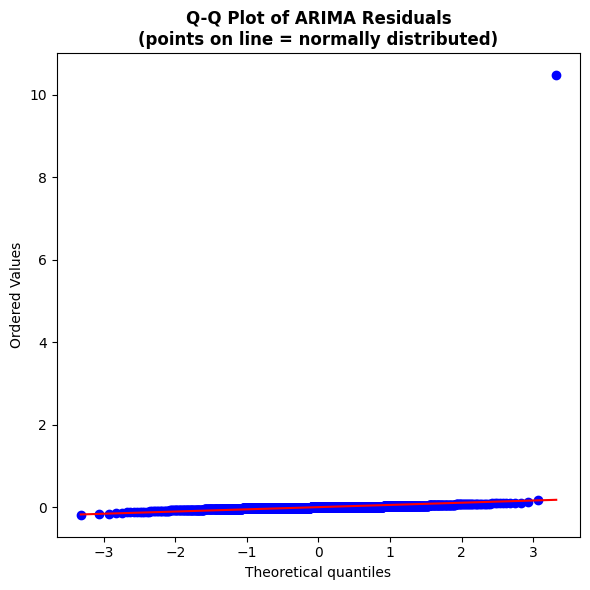

In [24]:
# Plot 8: Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of ARIMA Residuals\n(points on line = normally distributed)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_qq_plot.png', bbox_inches='tight')
plt.show()


In [25]:
# Ljung-Box test for autocorrelation in residuals
lb_result = acorr_ljungbox(residuals, lags=[5, 10, 15, 20], return_df=True)

print("=== Ljung-Box Test ===")
print("H₀: Residuals are uncorrelated (white noise)")
print("Reject H₀ if p-value < 0.05\n")
print(lb_result[['lb_stat', 'lb_pvalue']].rename(columns={
    'lb_stat': 'LB Statistic', 'lb_pvalue': 'p-value'
}).round(4))

# Shapiro-Wilk normality test
sample = residuals.sample(min(len(residuals), 3000), random_state=42)
sw_stat, sw_p = stats.shapiro(sample)

print("\n=== Shapiro-Wilk Normality Test ===")
print("H₀: Residuals are normally distributed")
print(f"  Statistic : {sw_stat:.6f}")
print(f"  p-value   : {sw_p:.6f}")
conclusion = "Fail to reject H₀ — residuals are approximately normal ✓" if sw_p > 0.05 \
             else "Reject H₀ — residuals deviate from normality ✗"
print(f"  ➜ {conclusion}")
print("\nNote: For large samples, Shapiro-Wilk is very sensitive. Inspect the Q-Q plot too.")


=== Ljung-Box Test ===
H₀: Residuals are uncorrelated (white noise)
Reject H₀ if p-value < 0.05

    LB Statistic  p-value
5         0.2493   0.9985
10        0.5480   1.0000
15        0.6141   1.0000
20        0.8365   1.0000

=== Shapiro-Wilk Normality Test ===
H₀: Residuals are normally distributed
  Statistic : 0.042153
  p-value   : 0.000000
  ➜ Reject H₀ — residuals deviate from normality ✗

Note: For large samples, Shapiro-Wilk is very sensitive. Inspect the Q-Q plot too.


## Step 6e — Residual Diagnostics

#### 6f. ARIMA Rolling Forecast

In [26]:
# Rolling one-step-ahead ARIMA forecast
print(f"Running rolling ARIMA{BEST_ORDER} forecast on {len(test_series)} test observations...")
print("(This may take a minute — we refit the model at each step)")

arima_preds = []
history     = list(np.log(train_series))   # start with log-price history

for i, actual_price in enumerate(test_series.values):
    m = ARIMA(history, order=BEST_ORDER)
    f = m.fit()
    log_forecast = f.forecast()[0]
    arima_preds.append(np.exp(log_forecast))
    history.append(np.log(actual_price))
    if (i + 1) % 20 == 0:
        print(f"  Step {i+1}/{len(test_series)} done")

arima_preds = np.array(arima_preds)
print("Forecasting complete.")


Running rolling ARIMA(1, 1, 0) forecast on 274 test observations...
(This may take a minute — we refit the model at each step)
  Step 20/274 done
  Step 40/274 done
  Step 60/274 done
  Step 80/274 done
  Step 100/274 done


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 120/274 done
  Step 140/274 done
  Step 160/274 done
  Step 180/274 done
  Step 200/274 done


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 220/274 done
  Step 240/274 done


c:\Users\USER\anaconda3\envs\tf\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Step 260/274 done
Forecasting complete.


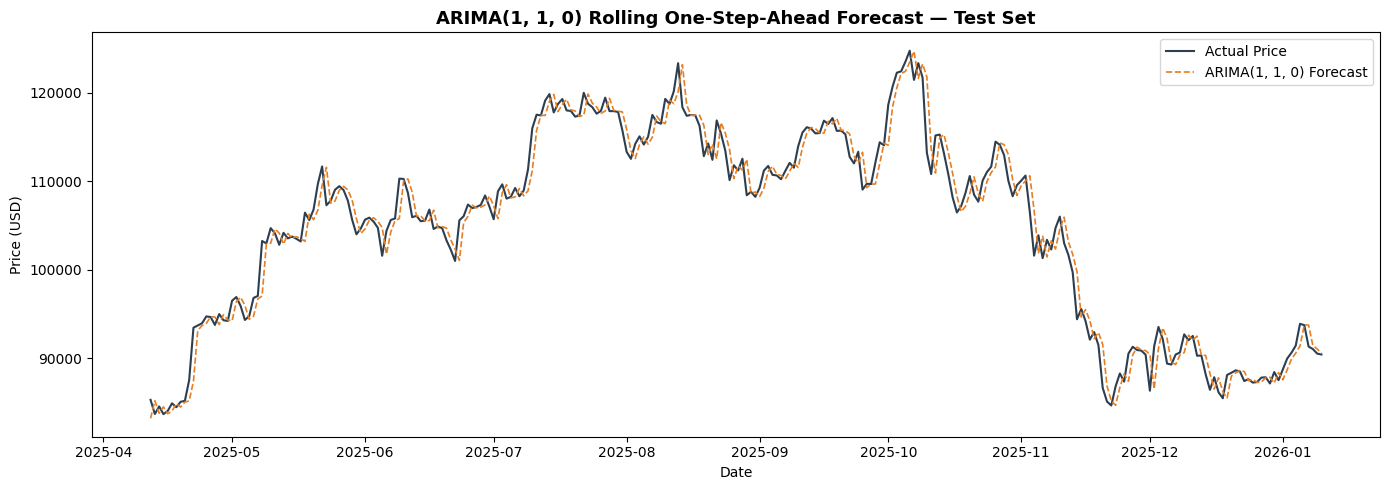

ARIMA(1, 1, 0) Test Metrics:
  RMSE : 1,932.96 USD
  MAE  : 1,426.95 USD
  R²   : 0.9691


In [27]:
# Plot 9: ARIMA forecast vs actual
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_series.index, test_series.values, color='#2C3E50',
        linewidth=1.5, label='Actual Price')
ax.plot(test_series.index, arima_preds, color='#E67E22',
        linewidth=1.2, linestyle='--', label=f'ARIMA{BEST_ORDER} Forecast')
ax.set_title(f'ARIMA{BEST_ORDER} Rolling One-Step-Ahead Forecast — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('09_arima_forecast.png', bbox_inches='tight')
plt.show()

rmse_arima = math.sqrt(mean_squared_error(test_series.values, arima_preds))
mae_arima  = mean_absolute_error(test_series.values, arima_preds)
r2_arima   = r2_score(test_series.values, arima_preds)
print(f"ARIMA{BEST_ORDER} Test Metrics:")
print(f"  RMSE : {rmse_arima:,.2f} USD")
print(f"  MAE  : {mae_arima:,.2f} USD")
print(f"  R²   : {r2_arima:.4f}")


## Step 6f — ARIMA Rolling One-Step-Ahead Forecast

### 7. Feature Selection — Correlation Heatmap

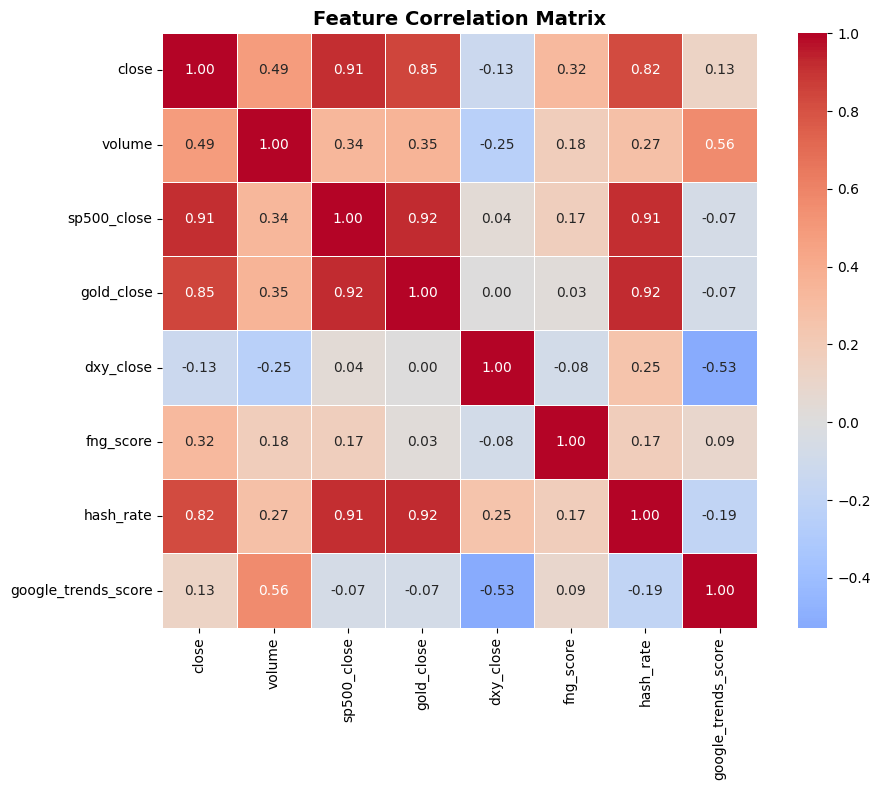

=== Correlation with Bitcoin Close Price (sorted) ===
sp500_close            0.9122
gold_close             0.8493
hash_rate              0.8241
volume                 0.4881
fng_score              0.3230
google_trends_score    0.1341
dxy_close             -0.1270
Name: close, dtype: float64


In [28]:
# Features available in the dataset (excluding leakage columns)
FEATURE_COLS = ['close', 'volume', 'sp500_close', 'gold_close',
                'dxy_close', 'fng_score', 'hash_rate', 'google_trends_score']

corr = df[FEATURE_COLS].corr()

# Plot 10: Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("=== Correlation with Bitcoin Close Price (sorted) ===")
print(corr['close'].drop('close').sort_values(ascending=False).round(4))


## Step 7 — Feature Correlation Heatmap

### 8. Multivariate LSTM & BiLSTM Models

In [29]:
FEATURES = ["close", "volume", "sp500_close", "gold_close",
           "dxy_close", "fng_score", "hash_rate", "google_trends_score"]

train_multi = df[FEATURES].iloc[:split_idx]
test_multi  = df[FEATURES].iloc[split_idx:]

multi_scaler = MinMaxScaler(feature_range=(0, 1))
train_multi_scaled = multi_scaler.fit_transform(train_multi)
test_multi_scaled  = multi_scaler.transform(test_multi)   # FIX: removed duplicate assignment

target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_multi[["close"]])

print("Data scaled. Train shape:", train_multi_scaled.shape)
print("Test shape :", test_multi_scaled.shape)


Data scaled. Train shape: (1552, 8)
Test shape : (274, 8)


## Step 8a — Feature Scaling for LSTM


In [30]:
def create_multivariate_sequences(data, window_size=14):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size : i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 14
X_train_m, y_train_m = create_multivariate_sequences(train_multi_scaled, WINDOW_SIZE)
full_test_multi = np.concatenate([train_multi_scaled[-WINDOW_SIZE:], test_multi_scaled])
X_test_m, y_test_m = create_multivariate_sequences(full_test_multi, WINDOW_SIZE)

n_features = X_train_m.shape[2]
predictions_dict = {"ARIMA (baseline)": arima_preds}
print(f"Sequences created.")
print(f"X_train_m shape : {X_train_m.shape}  →  (samples, timesteps, features)")
print(f"X_test_m  shape : {X_test_m.shape}")


Sequences created.
X_train_m shape : (1538, 14, 8)  →  (samples, timesteps, features)
X_test_m  shape : (274, 14, 8)


## Step 8b — Sliding Window Sequence Creation

#### 8c. Model 1 — Multivariate LSTM

In [31]:
# Model 1: Multivariate LSTM
print("Training Multivariate LSTM...")

mv_lstm_model = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),
    LSTM(100, return_sequences=True),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])
mv_lstm_model.compile(optimizer='adam', loss='mean_squared_error')
mv_lstm_model.fit(X_train_m, y_train_m, batch_size=32, epochs=50, verbose=0)

mv_lstm_preds_scaled = mv_lstm_model.predict(X_test_m, verbose=0)
predictions_dict['Multivariate LSTM'] = target_scaler.inverse_transform(mv_lstm_preds_scaled).flatten()
print("Done.")


Training Multivariate LSTM...
Done.


## Step 8c — Multivariate LSTM


#### 8d. Model 2 — Multivariate BiLSTM

In [32]:
# Model 2: Multivariate BiLSTM
print("Training Multivariate BiLSTM...")

mv_bilstm_model = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),
    Bidirectional(LSTM(100, return_sequences=True)),
    Bidirectional(LSTM(50, return_sequences=False)),
    Dense(25),
    Dense(1)
])
mv_bilstm_model.compile(optimizer='adam', loss='mean_squared_error')
mv_bilstm_model.fit(X_train_m, y_train_m, batch_size=32, epochs=50, verbose=0)

mv_bilstm_preds_scaled = mv_bilstm_model.predict(X_test_m, verbose=0)
predictions_dict['Multivariate BiLSTM'] = target_scaler.inverse_transform(mv_bilstm_preds_scaled).flatten()
print("Done.")


Training Multivariate BiLSTM...
Done.


## Step 8d — Multivariate Bidirectional LSTM (BiLSTM)

#### 8e. Model 3 — Hybrid ARIMA + Multivariate LSTM

In [33]:
print("Building Optimized Hybrid Model...")

fitted_log_train = arima_fitted.fittedvalues[1:]
actual_log_train = np.log(train_series).loc[fitted_log_train.index]
train_residuals = (actual_log_train - fitted_log_train).values.reshape(-1, 1)

res_scaler = MinMaxScaler(feature_range=(-1, 1))
train_res_scaled = res_scaler.fit_transform(train_residuals)

train_ext_scaled = train_multi_scaled[1:, 1:] # Drop first row, take col 1 to end

train_hyb_data = np.column_stack([train_res_scaled, train_ext_scaled])
X_tr_hyb, y_tr_hyb = create_multivariate_sequences(train_hyb_data, WINDOW_SIZE)

test_residuals_log = (np.log(test_series.values) - np.log(arima_preds)).reshape(-1, 1)
test_res_scaled = res_scaler.transform(test_residuals_log)
test_ext_scaled = test_multi_scaled[:, 1:]
test_hyb_data = np.column_stack([test_res_scaled, test_ext_scaled])

full_test_hyb = np.concatenate([train_hyb_data[-WINDOW_SIZE:], test_hyb_data])
X_te_hyb, _ = create_multivariate_sequences(full_test_hyb, WINDOW_SIZE)

hybrid_mv_lstm = Sequential([
    Input(shape=(WINDOW_SIZE, train_hyb_data.shape[1])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1)
])
hybrid_mv_lstm.compile(optimizer='adam', loss='mse')
hybrid_mv_lstm.fit(X_tr_hyb, y_tr_hyb, epochs=50, batch_size=32, verbose=0)

pred_res_scaled = hybrid_mv_lstm.predict(X_te_hyb, verbose=0)
pred_res_log = res_scaler.inverse_transform(pred_res_scaled).flatten()

predictions_dict['Hybrid ARIMA+MV LSTM'] = np.exp(np.log(arima_preds) + pred_res_log)
print("Hybrid Model Update Complete.")

Building Optimized Hybrid Model...
Hybrid Model Update Complete.


## Step 8e — Hybrid ARIMA + Multivariate LSTM

### 9. Model Comparison

In [34]:
# Preview predictions
print("=== Model Predictions Preview (first 10 values) ===")
for model_name, preds in predictions_dict.items():
    print(f"\n{model_name}:")
    print(np.round(preds[:10], 2))


=== Model Predictions Preview (first 10 values) ===

ARIMA (baseline):
[83195.02 85185.15 83770.48 84495.9  83715.94 84014.11 84848.97 84474.79
 85030.18 85168.31]

Multivariate LSTM:
[80842.86 82774.65 81164.98 81174.34 80855.98 80192.82 80917.2  80720.96
 80896.47 81276.25]

Multivariate BiLSTM:
[81777.3  83683.02 82839.48 82419.31 82153.61 81913.71 82635.96 82332.6
 82336.44 82569.3 ]

Hybrid ARIMA+MV LSTM:
[83361.39 85271.89 84155.9  84648.98 83738.57 83866.24 84579.63 84100.05
 84563.16 84647.64]


In [35]:
# Compute metrics for all models
actuals = test_series.values
metrics_list = []

for model_name, preds in predictions_dict.items():
    actuals_arr = np.array(actuals)
    preds_arr   = np.array(preds)
    mask = ~np.isnan(actuals_arr) & ~np.isnan(preds_arr)
    actuals_clean = actuals_arr[mask]
    preds_clean   = preds_arr[mask]

    if len(actuals_clean) == 0:
        print(f"{model_name}: No valid data after removing NaNs")
        continue

    rmse = math.sqrt(mean_squared_error(actuals_clean, preds_clean))
    mae  = mean_absolute_error(actuals_clean, preds_clean)
    r2   = r2_score(actuals_clean, preds_clean)

    metrics_list.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})

    print(f"{model_name}")
    print(f"  RMSE: {rmse:,.2f} USD")
    print(f"  MAE : {mae:,.2f} USD")
    print(f"  R²  : {r2:.4f}")
    print("-" * 40)

df_metrics = pd.DataFrame(metrics_list)
print("\n=== Performance Metrics Table ===")
display(df_metrics)

ARIMA (baseline)
  RMSE: 1,932.96 USD
  MAE : 1,426.95 USD
  R²  : 0.9691
----------------------------------------
Multivariate LSTM
  RMSE: 4,200.04 USD
  MAE : 3,738.01 USD
  R²  : 0.8543
----------------------------------------
Multivariate BiLSTM
  RMSE: 3,365.72 USD
  MAE : 2,836.37 USD
  R²  : 0.9065
----------------------------------------
Hybrid ARIMA+MV LSTM
  RMSE: 2,241.71 USD
  MAE : 1,618.99 USD
  R²  : 0.9585
----------------------------------------

=== Performance Metrics Table ===


,Model,RMSE,MAE,R²
0,ARIMA (baseline),1932.957675,1426.953170,0.969145
1,Multivariate LSTM,4200.043615,3738.014941,0.854323
2,Multivariate BiLSTM,3365.721675,2836.365220,0.906451
3,Hybrid ARIMA+MV LSTM,2241.714376,1618.985822,0.958501


## Step 9a — Model Performance Metrics

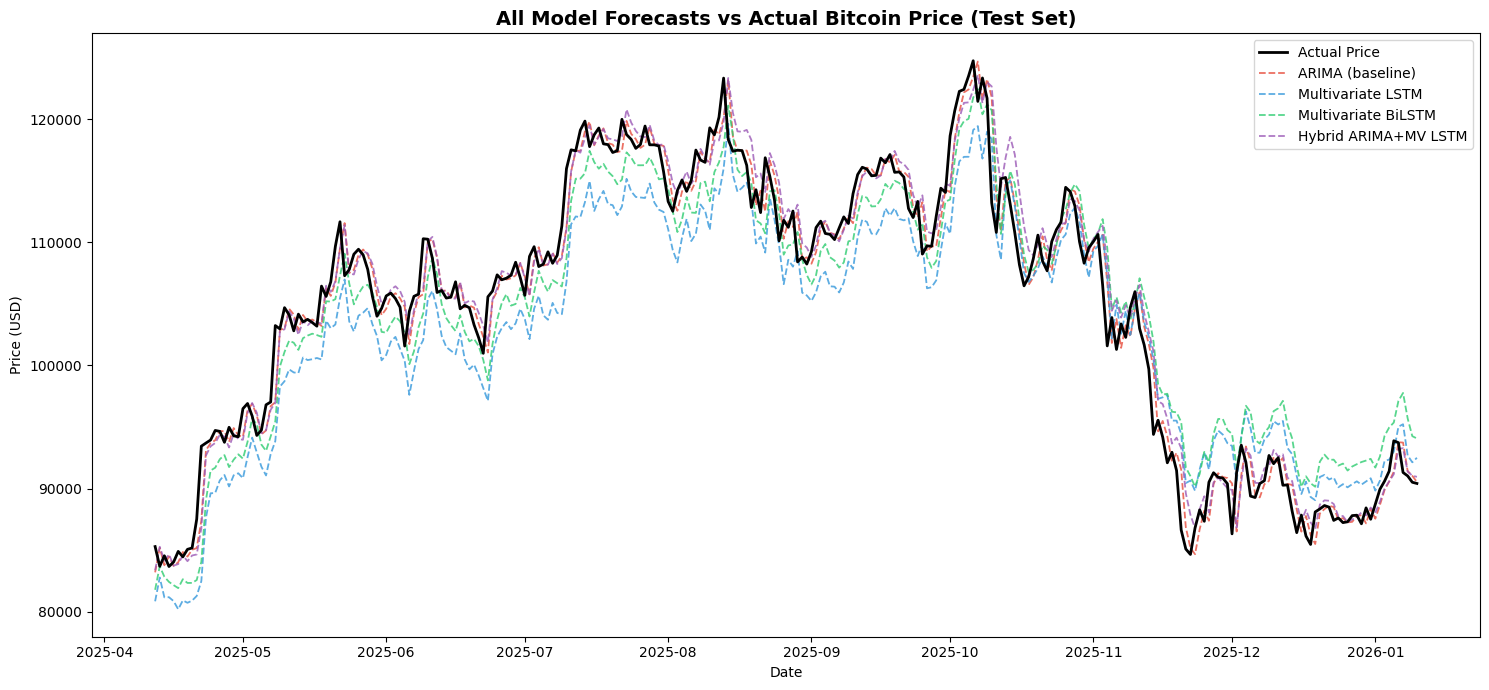

In [36]:
# Plot 13: All forecasts vs actual price
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(test_series.index, actuals, color='black', linewidth=2, label='Actual Price', zorder=5)

colors_map = {
    'ARIMA (baseline)'     : '#E74C3C',
    'Multivariate LSTM'    : '#3498DB',
    'Multivariate BiLSTM'  : '#2ECC71',
    'Hybrid ARIMA+MV LSTM' : '#9B59B6',
}

for model_name, preds in predictions_dict.items():
    ax.plot(test_series.index, preds,
            label=model_name, linestyle='--', linewidth=1.3, alpha=0.8,
            color=colors_map.get(model_name, 'grey'))

ax.set_title('All Model Forecasts vs Actual Bitcoin Price (Test Set)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('13_all_forecasts.png', bbox_inches='tight')
plt.show()


## Step 9b — All Forecasts vs Actual Price Plot

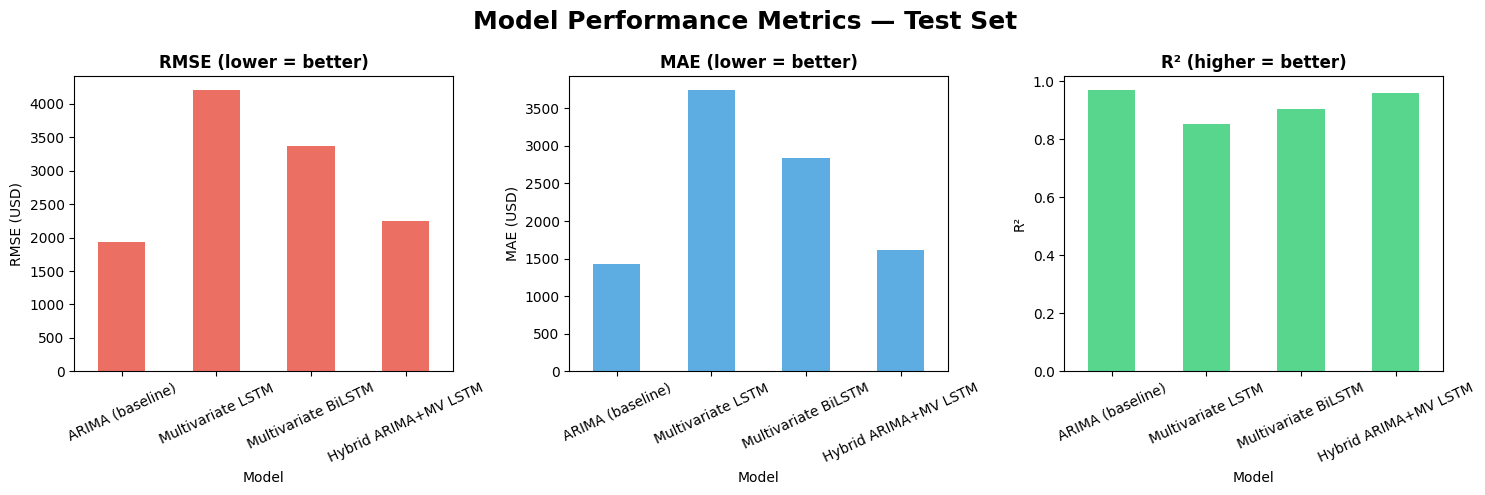

In [37]:
# Plot 14: Metrics bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_plot = df_metrics.set_index('Model')

metrics_plot['RMSE'].plot(kind='bar', ax=axes[0], color='#E74C3C', alpha=0.8)
axes[0].set_title('RMSE (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE (USD)')
axes[0].tick_params(axis='x', rotation=25)

metrics_plot['MAE'].plot(kind='bar', ax=axes[1], color='#3498DB', alpha=0.8)
axes[1].set_title('MAE (lower = better)', fontweight='bold')
axes[1].set_ylabel('MAE (USD)')
axes[1].tick_params(axis='x', rotation=25)

metrics_plot['R²'].plot(kind='bar', ax=axes[2], color='#2ECC71', alpha=0.8)
axes[2].set_title('R² (higher = better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Model Performance Metrics — Test Set', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('14_metrics_comparison.png', bbox_inches='tight')
plt.show()


### 9d. Predicted vs. Actual Analysis

This visualization plots the predicted values directly against the ground truth.
- **Diagonal Line (y=x)**: Represents perfect prediction.
- **Clustering**: Tight clustering around the line indicates high accuracy.
- **Bias**: Points consistently above or below the line reveal systematic over- or under-estimation.

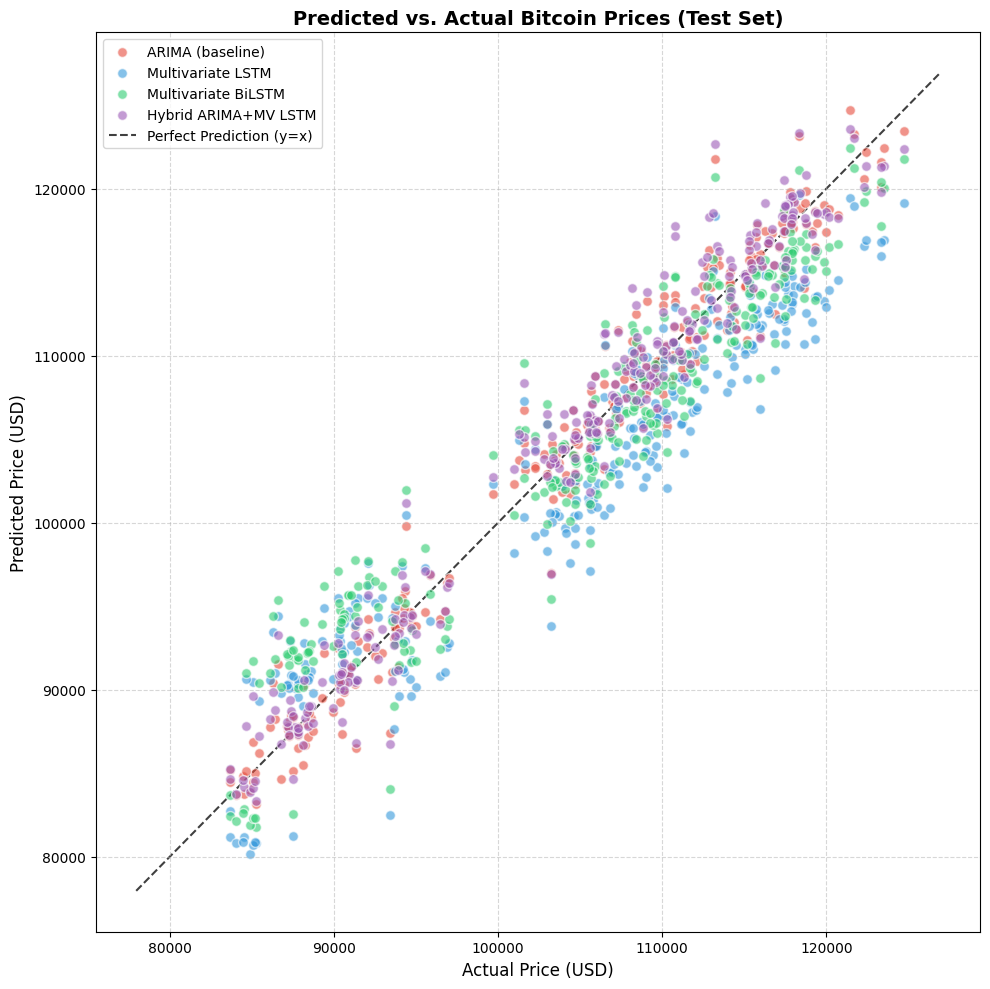

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

# Define model colors consistent with previous plots
colors_map = {
    'ARIMA (baseline)': '#E74C3C',
    'Multivariate LSTM': '#3498DB',
    'Multivariate BiLSTM': '#2ECC71',
    'Hybrid ARIMA+MV LSTM': '#9B59B6',
}

actuals = test_series.values

for model_name, preds in predictions_dict.items():
    plt.scatter(actuals, preds,
                alpha=0.6,
                label=model_name,
                color=colors_map.get(model_name, 'grey'),
                edgecolors='w',
                s=50)

# Identity line
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Prediction (y=x)')

plt.title('Predicted vs. Actual Bitcoin Prices (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('15_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

In [39]:

print("=== Pipeline Health Check ===")
print(f"Test set length: {len(test_series)}")
for name, preds in predictions_dict.items():
    print(f"{name} - Predictions shape: {preds.shape} | NaNs: {np.isnan(preds).sum()}")

# Check for feature alignment in Hybrid data
print(f"\nHybrid Train Data Shape: {train_hyb_data.shape}")
print(f"Hybrid Test Data Shape: {test_hyb_data.shape}")

if train_hyb_data.shape[1] == n_features:
    print("\n Feature counts match between standard and hybrid inputs.")
else:
    print("\n Feature counts differ (expected if only exogenous features are used in Hybrid).")

=== Pipeline Health Check ===
Test set length: 274
ARIMA (baseline) - Predictions shape: (274,) | NaNs: 0
Multivariate LSTM - Predictions shape: (274,) | NaNs: 0
Multivariate BiLSTM - Predictions shape: (274,) | NaNs: 0
Hybrid ARIMA+MV LSTM - Predictions shape: (274,) | NaNs: 0

Hybrid Train Data Shape: (1551, 8)
Hybrid Test Data Shape: (274, 8)

 Feature counts match between standard and hybrid inputs.


In [40]:
import pandas as pd
import numpy as np

audit_data = []
for name, preds in predictions_dict.items():
    error = np.abs(preds - test_series.values)
    max_err = np.max(error)
    mean_err = np.mean(error)
    audit_data.append({
        'Model': name,
        'Max Absolute Error (USD)': max_err,
        'Mean Absolute Error (USD)': mean_err,
        'Error Std Dev': np.std(error)
    })

audit_df = pd.DataFrame(audit_data)
print("=== Prediction Stability Audit ===")
display(audit_df.round(2))

# Logic Check: Verify that Hybrid is indeed a correction of ARIMA
correlation_check = np.corrcoef(arima_preds, predictions_dict['Hybrid ARIMA+MV LSTM'])[0, 1]
print(f"\nCorrelation between ARIMA and Hybrid predictions: {correlation_check:.4f}")
print("Note: A very high correlation (>0.99) suggests the LSTM component is making subtle refinements.")

=== Prediction Stability Audit ===


,Model,Max Absolute Error (USD),Mean Absolute Error (USD),Error Std Dev
0,ARIMA (baseline),8576.82,1426.95,1303.89
1,Multivariate LSTM,10960.25,3738.01,1915.10
2,Multivariate BiLSTM,9393.13,2836.37,1811.94
3,Hybrid ARIMA+MV LSTM,9455.40,1618.99,1550.54



Correlation between ARIMA and Hybrid predictions: 0.9970
Note: A very high correlation (>0.99) suggests the LSTM component is making subtle refinements.
